In [83]:
import numpy as np
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import eigs
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.optimize import curve_fit
import re


def site_index(x, y, z, Lx, Ly, Lz):
    return x + Lx * (y + Ly * z)

def build_geometry(Lx, Ly, Lz):

    bond_i = []
    bond_j = []
    z_bond = []

    directions = [
        (1, 0, 0),
        (0, 1, 0),
        (0, 0, 1)
    ]

    for x in range(Lx):
        for y in range(Ly):
            for z in range(Lz):

                i = site_index(x, y, z, Lx, Ly, Lz)

                for dx, dy, dz in directions:

                    x2 = (x + dx) % Lx
                    y2 = (y + dy) % Ly
                    z2 = (z + dz) % Lz

                    j = site_index(x2, y2, z2, Lx, Ly, Lz)

                    bond_i.append(i)
                    bond_j.append(j)
                    z_bond.append(dz == 1)

    return (
        np.array(bond_i),
        np.array(bond_j),
        np.array(z_bond)
    )

def build_hamiltonian(
    Lx, Ly, Lz,
    t, w, gamma,
    bond_i, bond_j, z_bond,
    rng
):

    N = Lx * Ly * Lz

    H = np.zeros((N, N), dtype=complex)

    tij = rng.uniform(
        t - w/2,
        t + w/2,
        size=len(bond_i)
    )

    hopping = tij - 1j * gamma * z_bond

    H[bond_i, bond_j] += hopping
    H[bond_j, bond_i] += hopping

    return H

def remove_sites(H, nu, Lx, Ly, Lz):
    remove_sites = [
        (0, 0, 0),
        (6, 2, 6),
        (4, 4, 2)
    ]

    # Coordinates to remove
    sites_to_remove = remove_sites[:nu]

    # Find their matrix indices
    remove_indices = [
        site_index(x, y, z, Lx, Ly, Lz)
        for x, y, z in sites_to_remove
    ]

    # Remove rows and columns
    H_new = np.delete(H, remove_indices, axis=0)
    H_new = np.delete(H_new, remove_indices, axis=1)

    return H_new

def build_sublattice_operator(Lx, Ly, Lz):
    N = Lx * Ly * Lz
    S = np.zeros((N, N))

    for x in range(Lx):
        for y in range(Ly):
            for z in range(Lz):
                i = site_index(x, y, z, Lx, Ly, Lz)

                S[i, i] = (-1) ** (x + y + z)

    return S

def plot_eigenvalues(H):
    # Sparse version
    H_sparse = csr_matrix(H)
    
    # 30 eigenvalues closest to zero
    eig_sparse = eigs(
        H_sparse,
        k=30,
        sigma=1e-6,
        return_eigenvectors=False
    )
    
    
    # Sort by distance from zero
    eig_sparse = eig_sparse[
        np.argsort(np.abs(eig_sparse))
    ]
    
    plt.scatter(
        eig_sparse.real,
        eig_sparse.imag,
        s=10
    )
    
    plt.xlabel(r"$\mathrm{Re}(z)$")
    plt.ylabel(r"$\mathrm{Im}(z)$")
    plt.axhline(0)
    plt.axvline(0)
    plt.show()

    return 


def generate_eigenvalue_data(
    Lx, Ly, Lz,
    t, w, gamma,
    n_samples, k,
    sigma, cutoff,
    nu
):

    # --------------------------------------------------
    # Build geometry once
    # --------------------------------------------------
    
    bond_i, bond_j, z_bond = build_geometry(
        Lx, Ly, Lz
    )
    
    # --------------------------------------------------
    # Preallocate arrays
    # --------------------------------------------------
    
    all_eigenvalues = np.empty(
        (n_samples, k),
        dtype=complex
    )
    
    smallest_moduli = np.empty(n_samples)
    
    # --------------------------------------------------
    # Generate samples
    # --------------------------------------------------
    
    for sample in tqdm(range(n_samples),desc=f"nu={nu}"):

        rng = np.random.default_rng(sample)
    
        H = build_hamiltonian(
            Lx, Ly, Lz,
            t, w, gamma,
            bond_i, bond_j, z_bond,
            rng
        )
        if nu>0:
            H = remove_sites(H, nu, Lx, Ly, Lz)
    
        H_sparse = csr_matrix(H)
    
        eigenvalues = eigs(
            H_sparse,
            k=k,
            sigma=sigma,
            return_eigenvectors=False
        )
    
        # Store the 30 closest eigenvalues(include 0)
        all_eigenvalues[sample, :] = eigenvalues

        tol = 1e-10
        eigenvalues = eigenvalues[np.abs(eigenvalues) > tol]
    
        # Store |z1|
        smallest_moduli[sample] = np.min(np.abs(eigenvalues))


    # --------------------------------------------------
    # Normalize
    # --------------------------------------------------
    
    scale = np.mean(smallest_moduli)
    
    normalized_eigenvalues = all_eigenvalues / scale
    
    z = normalized_eigenvalues
    
    mask = np.abs(z) < cutoff
    
    z_near = z[mask]
    
    filename = f"z_near_L={Lx}_n_samples={n_samples}_nu={nu}.npz"
    
    np.savez(
        filename,
        smallest_moduli=smallest_moduli,
        scale=scale,
        z_near=z_near,
        Lx=Lx,
        Ly=Ly,
        Lz=Lz,
        t=t,
        w=w,
        gamma=gamma,
        n_samples=n_samples,
        k=k
    )
    return 

def density(filename,num_bins):
    
    data = np.load(filename)
    
    z_near = data["z_near"]
    n_samples = data["n_samples"]

    tol = 1e-10
    z_near = z_near[np.abs(z_near) > tol]
    
    r=np.abs(z_near)
    
    bins = np.linspace(0, 1, num_bins)
    
    counts, edges = np.histogram(r, bins=bins)
    
    r_centers = (edges[:-1] + edges[1:]) / 2
    dr = edges[1] - edges[0]

    annulus_area = 2 * np.pi * r_centers * dr

    rho=counts/annulus_area/n_samples
    
    return r_centers,rho

def f_nu0(r, a, b):
    return a + b * r**2

def f_nu1(r, a, b):
    return -a * r**2 * np.log(r) + b * r**2

def f_nu2(r, a, b):
    return a * r**2 + b * r**4

def f_nu3(r, a, b):
    return a * r**2 + b * r**4

def fit_and_plot_densities(
    filenames,
    num_bins,
    r_min=0.05,
    r_max=1.0,
    colors = [
    "#4C78A8",  # muted blue
    "#B279A2",  # muted purple
    "#59A14F",  # muted green
    "#9C755F",  # muted brown
]
):

    # --------------------------------------------------
    # Fitting functions
    # --------------------------------------------------

    fit_functions = {
        0: f_nu0,
        1: f_nu1,
        2: f_nu2,
        3: f_nu3
    }

    # --------------------------------------------------
    # Plot
    # --------------------------------------------------

    plt.figure(figsize=(6, 4))

    fit_results = {}

    for nu in [0, 1, 2, 3]:

        # Load density
        r, rho = density(
            filenames[nu],
            num_bins[nu]
        )

        # --------------------------------------------------
        # Fit
        # --------------------------------------------------

        func = fit_functions[nu]

        popt, pcov = curve_fit(
            func,
            r,
            rho
        )

        fit_results[nu] = popt

        # --------------------------------------------------
        # Plot data as dots
        # --------------------------------------------------

        color = colors[nu]

        plt.loglog(
            r,
            rho,
            ".",
            color=color,
            markersize=6,
            label=rf"$\nu={nu}$"
        )

        # --------------------------------------------------
        # Plot fitted function
        # --------------------------------------------------

        r_line = np.logspace(
            np.log10(r_min),
            np.log10(r_max),
            300
        )

        rho_line = func(
            r_line,
            *popt
        )

        # Only plot positive fitted values
        positive = rho_line > 0

        plt.loglog(
            r_line[positive],
            rho_line[positive],
            "-",
            color=color
        )

        # Print parameters
        print(f"\nnu = {nu}")
        print(f"a = {popt[0]:.8g}")
        print(f"b = {popt[1]:.8g}")

    # --------------------------------------------------
    # Plot formatting
    # --------------------------------------------------

    plt.xlabel(
        r"$r=|z|/\langle |z_1|\rangle$"
    )

    plt.ylabel(r"$R_{1,\nu}(r)$")

    plt.grid(
        True,
        which="both"
    )

    plt.legend()

    plt.savefig("density_fit.png", dpi=600, bbox_inches="tight")

    plt.show()

    return fit_results

def plot_density(filename,num_bins):

    data = np.load(filename)

    z_near = data["z_near"]
    n_samples = data["n_samples"]

    # Remove zero eigenvalues
    tol = 1e-10
    z_near = z_near[np.abs(z_near) > tol]
    
    r_centers,rho=density(filename,num_bins)

    # --------------------------------------------------
    # 2D eigenvalue distribution
    # --------------------------------------------------

    fig,ax=plt.subplots(figsize=(6, 6))

    h=ax.hist2d(
        z_near.real,
        z_near.imag,
        bins=num_bins
    )

    circle = plt.Circle(
        (0, 0),
        1,
        fill=False,
        linewidth=2
    )
    
    ax.add_patch(circle)

    ax.set_xlabel(r"$\mathrm{Re}(z)$")
    ax.set_ylabel(r"$\mathrm{Im}(z)$")
    ax.set_aspect("equal")
    fig.colorbar(h[3], ax=ax, label="counts")

    plt.show()

    # --------------------------------------------------
    # Radial histogram
    # --------------------------------------------------

    r = np.abs(z_near)

    bins = np.linspace(0, 1, num_bins)

    counts, edges = np.histogram(r, bins=bins)

    r_centers = (edges[:-1] + edges[1:]) / 2
    dr = edges[1] - edges[0]

    # Annulus area
    annulus_area = (
        2 * np.pi * r_centers * dr
    )

    # --------------------------------------------------
    # Raw radial count vs annulus area
    # --------------------------------------------------

    fig, ax1 = plt.subplots(figsize=(6, 4))

    ax1.bar(
        r_centers,
        counts,
        width=dr,
        alpha=0.5,
        label="Eigenvalue count"
    )

    ax1.set_xlabel(
        r"$r=|z|/\langle |z_1|\rangle$"
    )
    ax1.set_ylabel("Number of eigenvalues")

    ax2 = ax1.twinx()

    ax2.plot(
        r_centers,
        annulus_area,
        marker="o",
        label=r"$2\pi r\,dr$"
    )

    ax2.set_ylabel("Annulus area")

    plt.show()

    # --------------------------------------------------
    # Radial density
    # --------------------------------------------------

    plt.figure(figsize=(6, 4))

    plt.loglog(
        r_centers,
        rho,
        marker="o"
    )

    plt.grid(True, which="both")

    plt.ylim(0.001, 0.6)

    plt.xlabel(
        r"$r=|z|/\langle |z_1|\rangle$"
    )
    plt.ylabel(r"$\rho(r)$")

    plt.show()

    return 



def comparison(files,function,bin_num):
    data = []
    
    for filename, label in files:
        r, rho = density(filename, bin_num)
        data.append((r, rho, label))
    
    colors = [f"C{i}" for i in range(len(data))]
    
    for i, (r, rho, label) in enumerate(data):
    
        color = colors[i]
    
        # --------------------------------------------------
        # Fit
        # --------------------------------------------------
    
        popt, pcov = curve_fit(
            function,
            r,
            rho
        )
    
        a, b = popt

        rho_fit = function(r, *popt)
        
        log_residual = np.log(rho) - np.log(rho_fit)
        print([np.log(rho), np.log(rho_fit)])
        
        rms = np.sqrt(np.mean(log_residual**2))
    
        # --------------------------------------------------
        # Plot data
        # --------------------------------------------------
    
        plt.loglog(
            r,
            rho,
            ".-",
            color=color,
            markersize=10-2*i,
            label=label
        )
    
        # --------------------------------------------------
        # Plot fitted function
        # --------------------------------------------------
    
        r_line = np.logspace(
            np.log10(np.min(r)),
            np.log10(np.max(r)),
            300
        )
    
        rho_line = function(
            r_line,
            *popt
        )
    
        # Only plot positive fitted values
        positive = rho_line > 0
    
        plt.loglog(
            r_line[positive],
            rho_line[positive],
            "-",
            color="black",
            alpha=0.2,
            label=f"fit{i}:a = {a:.3g}, b = {b:.3g}, RMS log residual = {rms:.2g}"
        )
    
        
        
    
    plt.grid(
            True,
            which="both"
        )
    plt.xlabel(r"$r$")
    plt.ylabel(r"$\rho(r)$")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return 

def combine_files(file1,file2):
    
    data1 = np.load(file1)
    data2 = np.load(file2)
    
    # --------------------------------------------------
    # Recover the original eigenvalues
    # --------------------------------------------------
    
    eigenvalues1 = data1["z_near"] * data1["scale"]
    eigenvalues2 = data2["z_near"] * data2["scale"]
    
    # --------------------------------------------------
    # Combine
    # --------------------------------------------------
    
    eigenvalues = np.concatenate([eigenvalues1, eigenvalues2])
    
    smallest_moduli = np.concatenate([
        data1["smallest_moduli"],
        data2["smallest_moduli"]
    ])
    
    # --------------------------------------------------
    # New scale
    # --------------------------------------------------
    
    scale = np.mean(smallest_moduli)
    
    # --------------------------------------------------
    # Rescale eigenvalues
    # --------------------------------------------------
    
    z_near = eigenvalues / scale
    
    # --------------------------------------------------
    # New number of samples
    # --------------------------------------------------
    
    n_samples = data1["n_samples"] + data2["n_samples"]
    
    # --------------------------------------------------
    # Save
    # --------------------------------------------------
    
    nu = int(re.search(r"nu=(\d+)", file1).group(1))
    filename = f"z_near_L={data1["Lx"]}_n_samples={n_samples}_nu={nu}.npz"
    
    np.savez(
        filename,
        smallest_moduli=smallest_moduli,
        scale=scale,
        z_near=z_near,
        Lx=data1["Lx"],
        Ly=data1["Ly"],
        Lz=data1["Lz"],
        t=data1["t"],
        w=data1["w"],
        gamma=data1["gamma"],
        n_samples=n_samples,
        k=data1["k"]
    )

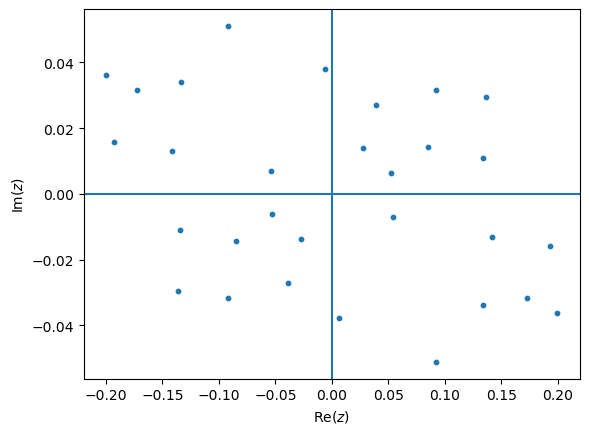

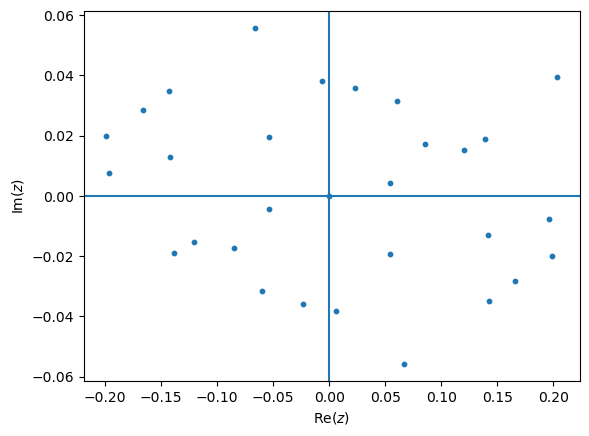

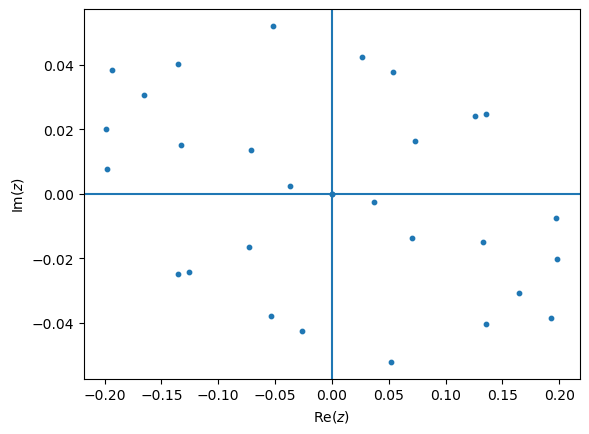

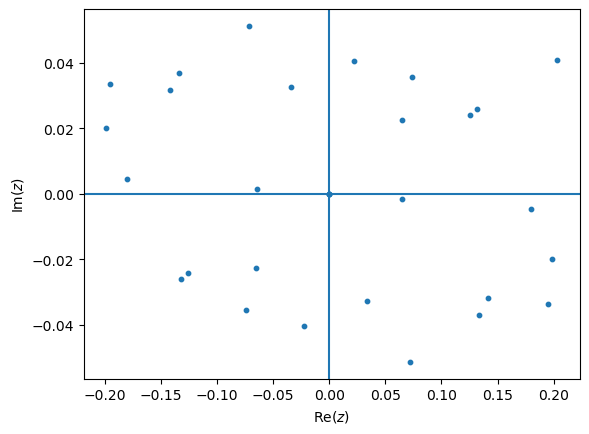

In [530]:
Lx = Ly = Lz = 8

t = 1
w = 1.6
gamma = 0.1

rng = np.random.default_rng(1)
bond_i, bond_j, z_bond = build_geometry(Lx, Ly, Lz)
H = build_hamiltonian(
            Lx, Ly, Lz,
            t, w, gamma,
            bond_i, bond_j, z_bond,
            rng
        )
plot_eigenvalues(H)
plot_eigenvalues(remove_sites(H, 1, Lx, Ly, Lz))
plot_eigenvalues(remove_sites(H, 2, Lx, Ly, Lz))
plot_eigenvalues(remove_sites(H, 3, Lx, Ly, Lz))

In [64]:
generate_eigenvalue_data(
    Lx=8, Ly =8, Lz = 8, t = 1, w = 1.6, gamma = 0.1,
    n_samples = 100000, k = 30, sigma = 1e-6, cutoff=3, nu=1
)

nu=1:  13%|███▋                        | 13286/100000 [15:28<1:41:02, 14.30it/s]


KeyboardInterrupt: 

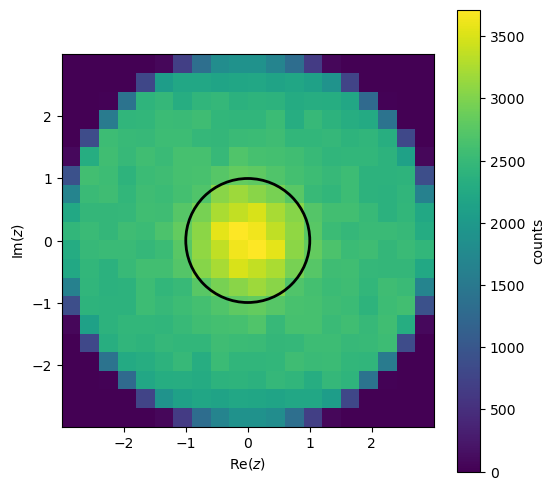

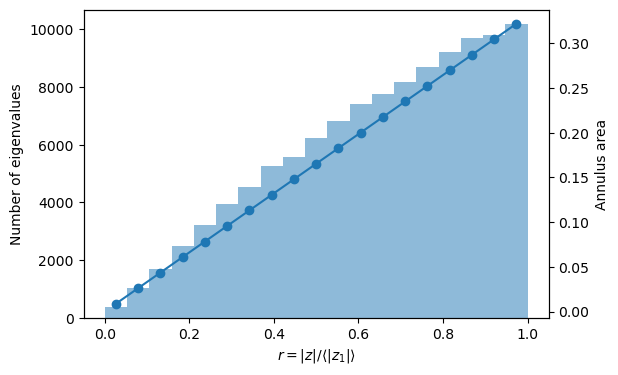

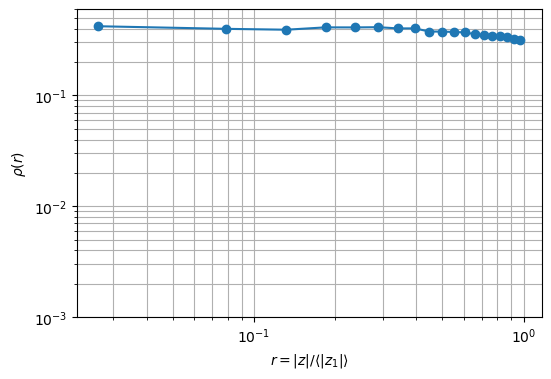

In [532]:
plot_density(filename = "z_near_L=10_n_samples=100000_nu=0.npz",num_bins=20)

In [77]:
import numpy as np
import time
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import eigs

L=10
Lx,Ly, Lz=L,L,L
t=1
w=1.6
gamma=0.1

# --------------------------------------------------
# 1. Build one Hamiltonian
# --------------------------------------------------

bond_i, bond_j, z_bond = build_geometry(
    Lx, Ly, Lz
)

H = build_hamiltonian(
    Lx, Ly, Lz,
    t, w, gamma,
    bond_i, bond_j, z_bond,
    rng
)

# Sparse version
H_sparse = csr_matrix(H)


# --------------------------------------------------
# 2. Dense eigensolver
# --------------------------------------------------

start = time.perf_counter()

eig_dense = np.linalg.eigvals(H)

dense_time = time.perf_counter() - start

# 10 eigenvalues closest to zero
eig_dense_10 = eig_dense[
    np.argsort(np.abs(eig_dense))[:10]
]


# --------------------------------------------------
# 3. Sparse eigensolver
# --------------------------------------------------

start = time.perf_counter()

eig_sparse = eigs(
    H_sparse,
    k=10,
    sigma=1e-6,
    return_eigenvectors=False
)

sparse_time = time.perf_counter() - start

# Sort by distance from zero
eig_sparse = eig_sparse[
    np.argsort(np.abs(eig_sparse))
]


# --------------------------------------------------
# 4. Compare
# --------------------------------------------------

print("Dense time :", dense_time)
print("Sparse time:", sparse_time)

print("\n10 closest eigenvalues:")
print("\nDense:")
print(eig_dense_10)

print("\nSparse:")
print(eig_sparse)

print("\nSpeedup:")
print(dense_time / sparse_time)

from scipy.optimize import linear_sum_assignment

cost = np.abs(
    eig_dense_10[:, None] - eig_sparse[None, :]
)

row, col = linear_sum_assignment(cost)

differences = cost[row, col]

print("Matched differences:")
print(differences)

print("Maximum matched difference:")
print(np.max(differences))

Dense time : 1.7695414589979919
Sparse time: 0.16354504199989606

10 closest eigenvalues:

Dense:
[-0.01040559-0.00350748j  0.01040559+0.00350748j  0.00029895+0.02356312j
 -0.00029895-0.02356312j  0.02342748-0.00804442j -0.02342748+0.00804442j
  0.03351647+0.00983556j -0.03351647-0.00983556j -0.02377423-0.04551826j
  0.02377423+0.04551826j]

Sparse:
[-0.01040559-0.00350748j  0.01040559+0.00350748j  0.00029895+0.02356312j
 -0.00029895-0.02356312j  0.02342748-0.00804442j -0.02342748+0.00804442j
 -0.03351647-0.00983556j  0.03351647+0.00983556j  0.02377423+0.04551826j
 -0.02377423-0.04551826j]

Speedup:
10.81990280695343
Matched differences:
[5.17495228e-16 5.97867262e-16 5.44571957e-16 1.10628537e-15
 4.10015389e-16 4.85837175e-16 8.05300416e-16 1.72689261e-15
 7.83549842e-16 2.73294659e-16]
Maximum matched difference:
1.7268926064286122e-15


In [5]:
from joblib import Parallel, delayed

def run_nu(nu):
    return generate_eigenvalue_data(
        Lx=8, Ly=8, Lz=8,
        t=1, w=1.6, gamma=0.1,
        n_samples=100000,
        k=30,
        sigma=1e-6,
        cutoff=3,
        nu=nu
    )

results = Parallel(n_jobs=4)(
    delayed(run_nu)(nu)
    for nu in [0, 1, 2, 3]
)

nu=2:  98%|█████████▊| 586107/600000 [8:53:39<10:21, 22.36it/s]Exception ignored in: <function ResourceTracker.__del__ at 0x10756d800>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes
nu=2: 100%|██████████| 600000/600000 [9:04:08<00:00, 18.38it/s]  
Exception ignored in: <function ResourceTracker.__del__ at 0x11d5ed800>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errn


nu = 0
a = 0.42505529
b = -0.13421715

nu = 1
a = 1.1838058
b = 0.42126383

nu = 2
a = 1.1695407
b = -0.6850624

nu = 3
a = 1.0536648
b = -0.50906606


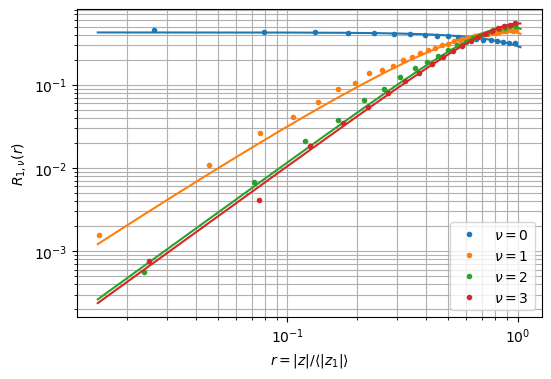

In [63]:
filenames = {
    0: "z_near_L=8_n_samples=600000_nu=0.npz",
    1: "z_near_L=8_n_samples=900000_nu=1.npz",
    2: "z_near_L=8_n_samples=1000000_nu=2.npz",
    3: "z_near_L=8_n_samples=1000000_nu=3.npz"
}

results = fit_and_plot_densities(
    filenames,
    num_bins=[20, 34, 22, 21],
    r_min=0.015,
    r_max=1.03,
    colors = ["C0","C1","C2","C3"]
)

[array([-0.92434213, -0.94982121, -0.88125854, -0.91095505, -0.94374651,
       -0.93989992, -0.98338056, -0.98795864, -1.03184247, -1.07923787,
       -1.06927615, -1.0729481 , -1.09660127, -1.12386174]), array([-0.92087159, -0.92312453, -0.92764569, -0.93446599, -0.94363269,
       -0.9552105 , -0.96928318, -0.98595559, -1.00535648, -1.02764206,
       -1.05300063, -1.08165849, -1.11388771, -1.15001628])]
[array([-0.79290937, -0.83339314, -0.86000017, -0.87468239, -0.89146214,
       -0.93175471, -0.95077287, -0.97581934, -1.01796733, -1.03701782,
       -1.07242576, -1.09022853, -1.12974565, -1.15354094]), array([-0.8548896 , -0.85813648, -0.86466204, -0.87453093, -0.8878428 ,
       -0.90473578, -0.92539141, -0.95004158, -0.97897794, -1.01256468,
       -1.05125601, -1.09562026, -1.14637368, -1.20442878])]
[array([-0.87226298, -0.9306513 , -0.90688533, -0.89163926, -0.89949613,
       -0.91636942, -0.97088518, -0.98283328, -0.99583535, -1.03908857,
       -1.07709616, -1.06804263, 

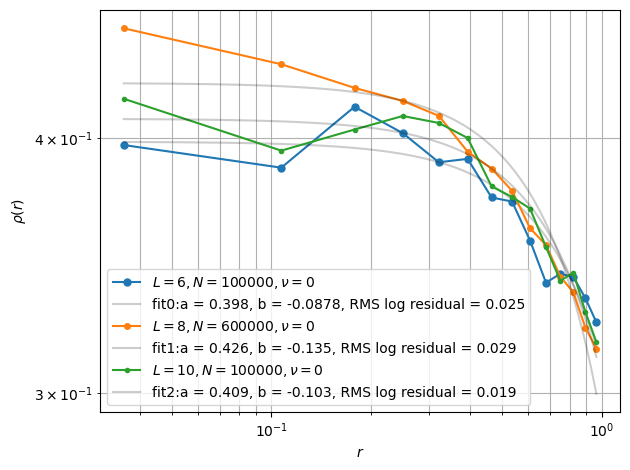

In [84]:
files0 = [
    ("z_near_L=6_n_samples=100000_nu=0.npz", r"$L=6,N=100000,\nu=0$"),
    ("z_near_L=8_n_samples=600000_nu=0.npz", r"$L=8,N=600000,\nu=0$"),
    ("z_near_L=10_n_samples=100000_nu=0.npz", r"$L=10,N=100000,\nu=0$"),
]
files1 = [
    ("z_near_L=6_n_samples=100000_nu=1.npz", r"$L=6,N=100000,\nu=1$"),
    ("z_near_L=8_n_samples=300000_nu=1.npz", r"$L=8,N=300000,\nu=1$"),
    ("z_near_L=8_n_samples=900000_nu=1.npz", r"$L=8,N=900000,\nu=1$"),
    ("z_near_L=10_n_samples=100000_nu=1.npz", r"$L=10,N=100000,\nu=1$"),
]

files2 = [
    ("z_near_L=10_n_samples=100000_nu=2.npz", r"$L=10,N=100000,\nu=2$"),
    ("z_near_L=8_n_samples=1000_nu=2.npz", r"$L=8,N=1000,\nu=2$"),
    ("z_near_L=8_n_samples=1000000_nu=2.npz", r"$L=8,N=1000000,\nu=2$"),
    ("z_near_L=12_n_samples=1000_nu=2.npz", r"$L=12,N=1000,\nu=2$"),
]

files3 = [
    ("z_near_L=10_n_samples=100000_nu=3.npz", r"$L=10,N=100000,\nu=3$"),
    ("z_near_L=8_n_samples=1000_nu=3.npz", r"$L=8,N=1000,\nu=2$"),
    ("z_near_L=8_n_samples=1000000_nu=3.npz", r"$L=8,N=1000000,\nu=3$"),
    ("z_near_L=12_n_samples=1000_nu=3.npz", r"$L=12,N=1000,\nu=2$"),
]
comparison(files0,f_nu0,15)

[array([       -inf, -4.97149305, -3.80834224, -3.33388426, -2.97906288,
       -2.47154852, -2.30000044, -2.17828504, -1.95826762, -1.78470554,
       -1.68451364, -1.52773605, -1.4287961 , -1.37977734, -1.28953404,
       -1.21782309, -1.17362331, -1.1484574 , -1.0621764 , -1.01190162,
       -0.99982151, -0.93869407, -0.93548406, -0.90083097, -0.86028468,
       -0.85357239, -0.82746025, -0.83211718, -0.83394337, -0.8012866 ,
       -0.7898184 , -0.80028543, -0.78979529]), array([-6.71431123, -4.79269514, -3.93068577, -3.37879307, -2.9772172 ,
       -2.66460547, -2.41088523, -2.19908916, -2.0187146 , -1.86281779,
       -1.72657638, -1.60651153, -1.50003712, -1.40518384, -1.32042279,
       -1.24454851, -1.17659904, -1.11579989, -1.06152404, -1.01326275,
       -0.97060421, -0.93321765, -0.90084168, -0.87327573, -0.85037404,
       -0.83204178, -0.81823294, -0.80895004, -0.80424554, -0.80422516,
       -0.8090535 , -0.81896231, -0.83426245])]
[array([       -inf, -4.5296603 , -3.61

/var/folders/g9/fkd49kn16tl535l274n2_9t80000gn/T/ipykernel_9558/2890956285.py:540: RuntimeWarning: divide by zero encountered in log
  log_residual = np.log(rho) - np.log(rho_fit)
/var/folders/g9/fkd49kn16tl535l274n2_9t80000gn/T/ipykernel_9558/2890956285.py:541: RuntimeWarning: divide by zero encountered in log
  print([np.log(rho), np.log(rho_fit)])


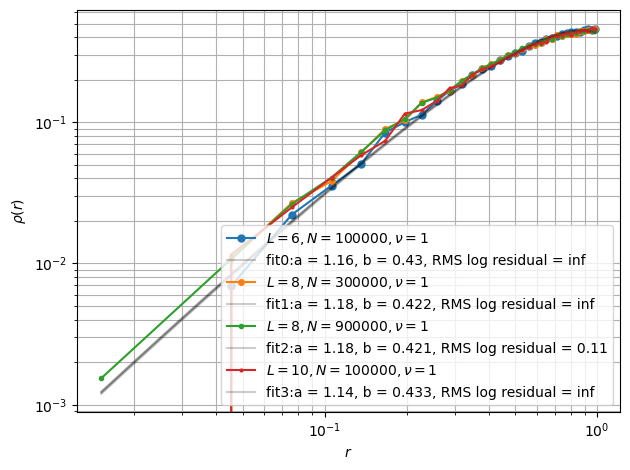

In [85]:
comparison(files1,f_nu1,34)

[array([-5.87546329, -4.40912623, -3.98839365, -3.40253284, -2.88530207,
       -2.35985556, -2.09127366, -1.92678697, -1.66464374, -1.54403767,
       -1.36985039, -1.24708622, -1.13506316, -1.02604059, -0.96027612,
       -0.85052222, -0.81728922, -0.76244334, -0.72092268, -0.66024887,
       -0.64748989]), array([-7.35192781, -5.15723327, -4.14066138, -3.47538466, -2.98307179,
       -2.59477687, -2.27655251, -2.00920655, -1.78087421, -1.5837585 ,
       -1.41251614, -1.26338676, -1.13369331, -1.02154423, -0.92565412,
       -0.84524031, -0.77997439, -0.72998064, -0.69588403, -0.67892298,
       -0.68116175])]
[array([       -inf,        -inf, -2.87973102, -3.21620326, -3.46751769,
       -1.4709638 , -1.75580092, -1.20575459, -1.80092136, -1.64978273,
       -1.42444379, -1.22773349, -1.3111151 , -1.03976945, -0.94870948,
       -1.27029311, -0.67245611, -0.69850679, -0.64710452, -0.75946749,
       -0.90632773]), array([-7.27985286, -5.08559896, -4.06991566, -3.40599044, -2.915515

/var/folders/g9/fkd49kn16tl535l274n2_9t80000gn/T/ipykernel_9558/2890956285.py:540: RuntimeWarning: divide by zero encountered in log
  log_residual = np.log(rho) - np.log(rho_fit)
/var/folders/g9/fkd49kn16tl535l274n2_9t80000gn/T/ipykernel_9558/2890956285.py:541: RuntimeWarning: divide by zero encountered in log
  print([np.log(rho), np.log(rho_fit)])


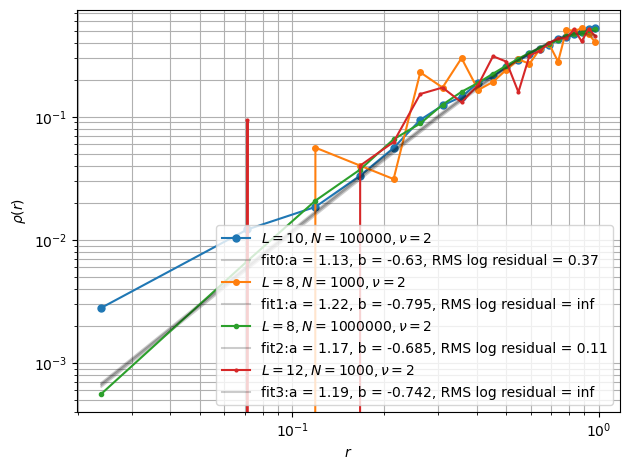

In [86]:
comparison(files2,f_nu2,22)

/var/folders/g9/fkd49kn16tl535l274n2_9t80000gn/T/ipykernel_9558/2890956285.py:540: RuntimeWarning: divide by zero encountered in log
  log_residual = np.log(rho) - np.log(rho_fit)
/var/folders/g9/fkd49kn16tl535l274n2_9t80000gn/T/ipykernel_9558/2890956285.py:541: RuntimeWarning: divide by zero encountered in log
  print([np.log(rho), np.log(rho_fit)])


[array([       -inf, -5.12574576, -4.28664467, -3.47630252, -2.92324413,
       -2.65391119, -2.3273929 , -1.99149456, -1.72623047, -1.60027019,
       -1.40374738, -1.24951086, -1.10581691, -1.01747742, -0.89099693,
       -0.83762476, -0.74209707, -0.66945446, -0.63810768, -0.55819757]), array([-7.37776362, -5.18270729, -4.16540669, -3.49902388, -3.00521143,
       -2.61500098, -2.29441559, -2.02422512, -1.7925169 , -1.59143383,
       -1.41555748, -1.2610332 , -1.12506513, -1.00561069, -0.90119049,
       -0.81076935, -0.73368469, -0.66961002, -0.6185479 , -0.58085308])]
[array([       -inf,        -inf,        -inf,        -inf, -2.17880365,
       -2.37947435, -2.14106333, -2.46648573, -1.80319151, -1.26778998,
       -1.63980715, -1.45884522, -1.40869543, -0.90251019, -0.80334363,
       -0.67472626, -0.73724661, -0.79608711, -0.5843422 , -0.4567241 ]), array([-7.43294785, -5.23748165, -4.21935646, -3.5517245 , -3.05622318,
       -2.66386325, -2.34064041, -2.06728986, -1.8318557

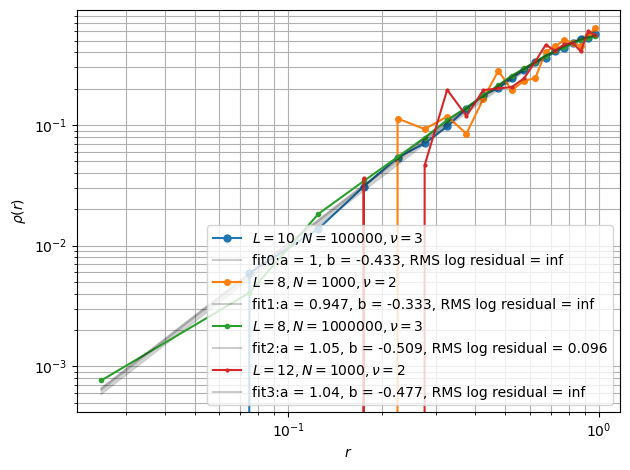

In [87]:
comparison(files3,f_nu3,21)

In [31]:
file1="z_near_L=8_n_samples=400000_nu=3.npz"
file2="z_near_L=8_n_samples=600000_nu=3.npz"
combine_files(file1,file2)

In [32]:
file1="z_near_L=8_n_samples=400000_nu=2.npz"
file2="z_near_L=8_n_samples=600000_nu=2.npz"
combine_files(file1,file2)

In [33]:
file1="z_near_L=8_n_samples=300000_nu=1.npz"
file2="z_near_L=8_n_samples=600000_nu=1.npz"
combine_files(file1,file2)